In [1]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt

## Part b

In [51]:
q0 = 1/8 * np.ones(8)
p = np.array([[0, 1/2, 1/2, 0, 0, 0, 0, 0], [0, 0, 1/2, 1/2, 0, 0, 0, 0], [1/2, 0, 0, 0, 1/2, 0, 0, 0], [1/3, 0, 1/3, 0, 1/3, 0, 0, 0], [0, 1/3, 0, 0, 0, 1/3, 1/3, 0], [0, 0,0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 1], [0, 0, 0, 0, 0, 0, 1, 0]])
q100 = q0 @ np.linalg.matrix_power(p, 100)
q101 = q100 @ p
print(q100)
print(q101)

[5.35201377e-08 5.16600068e-08 7.24662674e-08 2.99187156e-08
 5.35201377e-08 4.37499869e-01 2.67736426e-01 2.94763443e-01]
[4.62060389e-08 4.46001148e-08 6.25629775e-08 2.58300034e-08
 4.62060389e-08 4.37499887e-01 2.94763461e-01 2.67736426e-01]


In [52]:
# power iteration
d = 0.85
G = d * p + (1-d)/8 * np.ones((8,8))
print(f'G Matrix: \n {G}')
iters = 1
tol = 1e-10

q_next = q0 @ G
while np.linalg.norm(q_next - q, ord=1) > tol:
    q = q_next
    q_next = q @ G
    iters += 1

pi = q_next

# linear solve
A = G.T - np.eye(8)
A[-1, :] = [1, 1, 1, 1, 1, 1, 1, 1]
b = np.array([0, 0, 0, 0, 0, 0, 0, 1])
pi_solve = np.linalg.solve(A, b)

print(f'pi from power iteration: {pi}')
print(f'pi from linear solve: {pi_solve}')
print(f'Iteration Count: {iters}')


G Matrix: 
 [[0.01875    0.44375    0.44375    0.01875    0.01875    0.01875
  0.01875    0.01875   ]
 [0.01875    0.01875    0.44375    0.44375    0.01875    0.01875
  0.01875    0.01875   ]
 [0.44375    0.01875    0.01875    0.01875    0.44375    0.01875
  0.01875    0.01875   ]
 [0.30208333 0.01875    0.30208333 0.01875    0.30208333 0.01875
  0.01875    0.01875   ]
 [0.01875    0.30208333 0.01875    0.01875    0.01875    0.30208333
  0.30208333 0.01875   ]
 [0.01875    0.01875    0.01875    0.01875    0.01875    0.86875
  0.01875    0.01875   ]
 [0.01875    0.01875    0.01875    0.01875    0.01875    0.01875
  0.01875    0.86875   ]
 [0.01875    0.01875    0.01875    0.01875    0.01875    0.01875
  0.86875    0.01875   ]]
pi from power iteration: [0.07175665 0.06957763 0.09250788 0.04832049 0.07175665 0.26054035
 0.19826505 0.18727529]
pi from linear solve: [0.07175665 0.06957763 0.09250788 0.04832049 0.07175665 0.26054035
 0.19826505 0.18727529]
Iteration Count: 124


## Part c

In [61]:

# num surfers
R = 100
# upper bound and int because python be pythoning
T_max = int(1e5)
# what page we are on - starting from page 1
current_page = np.zeros(R, dtype=int)
# how many times has the surfer visited the page - important to approximate the stationary distribution
state_counts = np.zeros((R, 8))
# what values we actually care about for plotting
T_val = np.logspace(2, 5, 50, dtype=int)
# cumulative sum cuz we were told to vectorize and my previous methods were not
G_sum = np.cumsum(G, axis=1)
# the errors
rms = []

# loop that loop-dee-doop - sorry i'm so tired
for t in range(2, T_max + 1):
    # uniform random variable to then run through the sum and get the next state
    U = np.random.uniform(0, 1, size=(R,1))
    rows = G_sum[current_states]
    next = np.argmax(rows > U, axis=1)
    # set to the next state and modify the counts based on where we visited
    current_states = next
    state_counts[np.arange(R), current_states] += 1

    # once we actually get to the [1e2, 1e5] range - track the rms error
    if t in T_val:
        # get the approximated stationary distribution
        hat_pi = state_counts / t
        # get the max error
        max_err = np.max(np.abs(hat_pi - pi), axis=1)
        # append the root mean square errors and the times
        rms.append((t, np.sqrt(np.mean(max_err**2))))

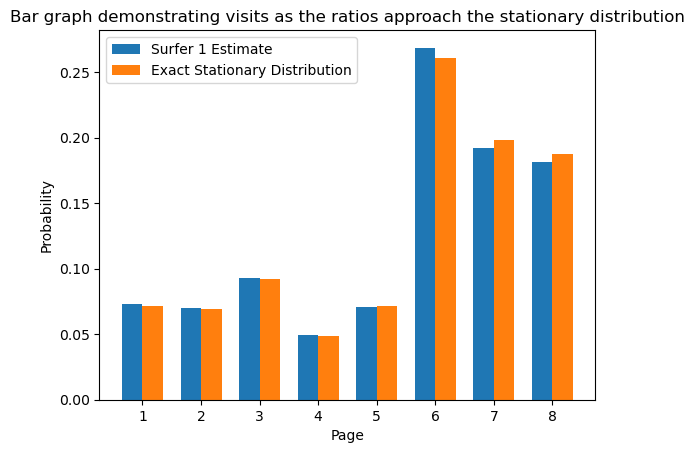

In [62]:
# consider surfer 1 just because
surfer_idx = 0
# how many tiems did they visit each state (of course divided by the total number of trials)
hat_pi1 = state_counts[surfer_idx, :] / T_max
x = np.arange(1, 8 + 1)
width = 0.35

plt.bar(x - width/2, hat_pi1, width, label="Surfer 1 Estimate")
plt.bar(x + width/2, pi, width, label="Exact Stationary Distribution")
plt.xlabel("Page")
plt.ylabel("Probability")
plt.xticks(x)
plt.legend()
plt.title('Bar graph demonstrating visits as the ratios approach the stationary distribution')
plt.show()

<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
C:\Users\madis\AppData\Local\Temp\ipykernel_6508\123510986.py:22: SyntaxWarning: invalid escape sequence '\s'
  plt.loglog(T_vals_used, comparison, label='$\sqrt{\pi_6(1-\pi_6)/T}$')


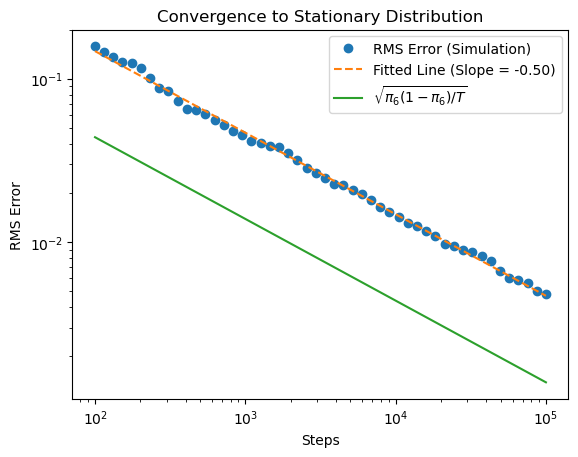

In [64]:
# plotting the plots
# put it into an array because arrays are different from lists
rms_array = np.array(rms)
# steps
T_vals_used = rms_array[:, 0]  
# rms
rms_val = rms_array[:, 1] 

fit_mask = (T_vals_used >= 1e2) & (T_vals_used <= 1e5)
fitted_T = T_vals_used[fit_mask]
fitted_rms = rms_val[fit_mask]

# Fit power-law line in log-log space - like in hw 3
slope, intercept = np.polyfit(np.log10(fitted_T), np.log10(fitted_rms), deg=1)
fitted_rms = 10**intercept * (T_vals_used**slope)

comparison = np.sqrt(pi[5] * (1 - pi[5]) / T_val)

# plot them loglog plots
plt.loglog(T_vals_used, rms_val, 'o', label='RMS Error (Simulation)')
plt.loglog(T_vals_used, fitted_rms, '--', label=f'Fitted Line (Slope = {slope:.2f})')
plt.loglog(T_vals_used, comparison, label='$\sqrt{\pi_6(1-\pi_6)/T}$')
plt.xlabel('Steps')
plt.ylabel('RMS Error')
plt.title('Convergence to Stationary Distribution')
plt.legend()
plt.show()